# **STEP 1: INSTALL REQUIRED PACKAGES**

In [1]:
# INSTALL REQUIRED PACKAGES

!pip install -q yfinance pandas numpy scikit-learn matplotlib seaborn plotly xgboost lightgbm

import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("✅ All libraries installed successfully")

✅ All libraries installed successfully


# **STEP 2: LOAD TSLA DATA**

In [3]:

# LOAD TSLA DATA

print("LOADING TSLA DATA")

# Download data
df = yf.download('TSLA', start='2015-01-01', end='2024-12-31', progress=False)
df = df.reset_index()

# Ensure 'Adj Close' column exists, if not, create it from 'Close'
if 'Adj Close' not in df.columns:
    df['Adj Close'] = df['Close']

df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

print(f"✅ Loaded {len(df)} days of data")
print(f"📅 From: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"💰 Price range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")

LOADING TSLA DATA
✅ Loaded 2515 days of data
📅 From: 2015-01-02 to 2024-12-30
💰 Price range: $9.49 - $475.90


In [4]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,14.620667
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,14.006000
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,14.085333
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,14.063333
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,14.041333
...,...,...,...,...,...,...,...
2510,2024-12-23,430.600006,434.510010,415.410004,431.000000,72698100,430.600006
2511,2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800,462.279999
2512,2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400,454.130005
2513,2024-12-27,431.660004,450.000000,426.500000,449.519989,82666800,431.660004


In [5]:
df.head() # first 5 row

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,14.620667
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,14.006000
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,14.085333
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,14.063333
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,14.041333


In [6]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2510,2024-12-23,430.600006,434.510010,415.410004,431.000000,72698100,430.600006
2511,2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800,462.279999
2512,2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400,454.130005
2513,2024-12-27,431.660004,450.000000,426.500000,449.519989,82666800,431.660004
2514,2024-12-30,417.410004,427.000000,415.750000,419.399994,64941000,417.410004


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2515 non-null   datetime64[ns]
 1   Open       2515 non-null   float64       
 2   High       2515 non-null   float64       
 3   Low        2515 non-null   float64       
 4   Close      2515 non-null   float64       
 5   Adj Close  2515 non-null   int64         
 6   Volume     2515 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 137.7 KB


In [8]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,2515,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03,2515.000000
mean,2019-12-31 01:37:54.512922624,115.564847,118.127021,112.871415,115.578935,1.123272e+08,115.564847
min,2015-01-02 00:00:00,9.578000,10.331333,9.403333,9.488000,1.062000e+07,9.578000
25%,2017-07-01 12:00:00,17.185000,17.480000,16.888333,17.174334,6.681690e+07,17.185000
50%,2019-12-31 00:00:00,28.502001,28.713333,27.333332,28.299999,9.286200e+07,28.502001
75%,2022-06-29 12:00:00,220.178337,225.253334,215.294998,220.825005,1.298032e+08,220.178337
max,2024-12-30 00:00:00,479.859985,488.540009,457.510010,475.899994,9.140820e+08,479.859985
std,NaN,114.104456,116.747743,111.357651,114.169550,7.408223e+07,114.104456


# **STEP 3: DATA CLEANING**

In [10]:
# DATA CLEANING

print("DATA CLEANING")

# Check missing values
print(f"Missing values: {df.isnull().sum().sum()}")

# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates(subset=['Date'])

print(f"✅ Clean data shape: {df.shape}")

DATA CLEANING
Missing values: 0
✅ Clean data shape: (2515, 7)


# **STEP 4: EXPLORATORY DATA ANALYSIS**

EXPLORATORY DATA ANALYSIS


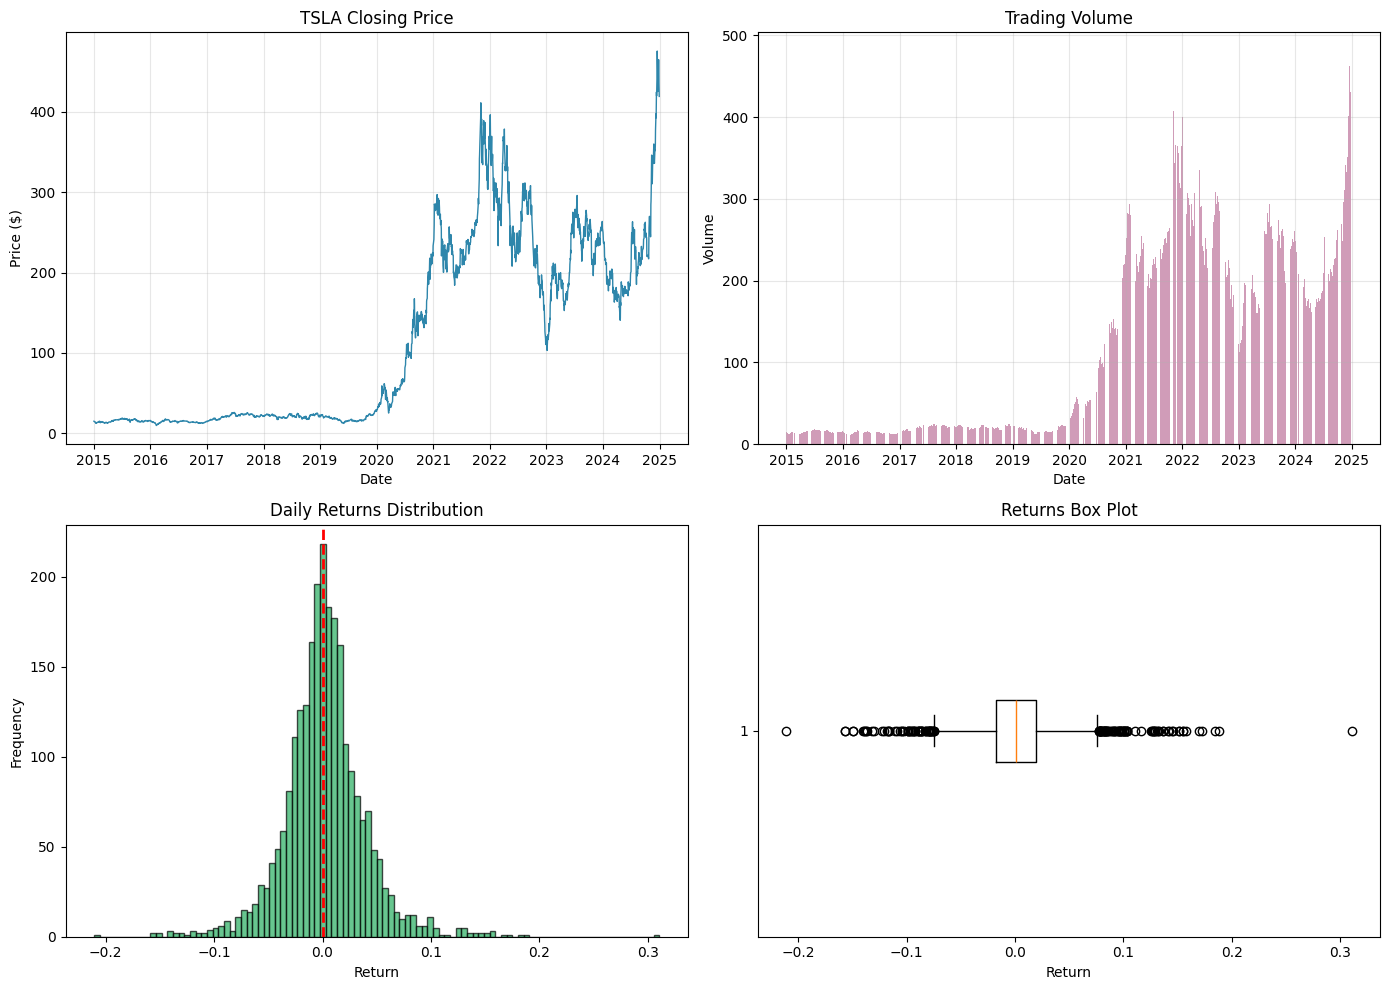


📈 Statistics:
Mean Return: 0.2044%
Std Return: 3.7925%
Positive Days: 51.47%


In [11]:

# EXPLORATORY DATA ANALYSIS

print("EXPLORATORY DATA ANALYSIS")

# Calculate returns
df['Return'] = df['Close'].pct_change()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price chart
axes[0, 0].plot(df['Date'], df['Close'], color='#2E86AB', linewidth=1)
axes[0, 0].set_title('TSLA Closing Price', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# Volume chart
axes[0, 1].bar(df['Date'], df['Volume'], color='#A23B72', alpha=0.5, width=1)
axes[0, 1].set_title('Trading Volume', fontsize=12)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].grid(True, alpha=0.3)

# Returns distribution
returns = df['Return'].dropna()
axes[1, 0].hist(returns, bins=100, color='#27AE60', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=12)
axes[1, 0].set_xlabel('Return')
axes[1, 0].set_ylabel('Frequency')

# Box plot
axes[1, 1].boxplot(returns, vert=False)
axes[1, 1].set_title('Returns Box Plot', fontsize=12)
axes[1, 1].set_xlabel('Return')

plt.tight_layout()
plt.show()

print(f"\n📈 Statistics:")
print(f"Mean Return: {returns.mean()*100:.4f}%")
print(f"Std Return: {returns.std()*100:.4f}%")
print(f"Positive Days: {(returns > 0).mean()*100:.2f}%")

# **STEP 5: FEATURE ENGINEERING**

In [13]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

#FEATURE ENGINEERING

print("FEATURE ENGINEERING")

def create_features(df):
    """Create advanced features for high accuracy"""

    df = df.copy()

    # 1. Price Returns (Multiple timeframes)
    for period in [1, 2, 3, 5, 10, 20, 50]:
        df[f'ret_{period}d'] = df['Close'].pct_change(period)
        df[f'log_ret_{period}d'] = np.log(df['Close'] / df['Close'].shift(period))

    # 2. Volume Features
    df['vol_ret'] = df['Volume'].pct_change()
    df['vol_ma_5'] = df['Volume'].rolling(5).mean()
    df['vol_ma_20'] = df['Volume'].rolling(20).mean()
    df['vol_ratio'] = df['Volume'] / df['vol_ma_20'] # Reverted: Directly assign Series
    df['vol_breakout'] = (df['vol_ratio'] > 1.5).astype(int)

    # 3. Moving Averages (Trend)
    for period in [5, 10, 20, 50, 100, 200]:
        df[f'sma_{period}'] = df['Close'].rolling(period).mean()
        df[f'ema_{period}'] = df['Close'].ewm(span=period).mean()
        df[f'price_sma_{period}'] = df['Close'] / df[f'sma_{period}']

    # 4. Moving Average Crossovers (Strong signals)
    df['ma_cross_5_20'] = (df['sma_5'] > df['sma_20']).astype(int)
    df['ma_cross_20_50'] = (df['sma_20'] > df['sma_50']).astype(int)
    df['ma_cross_50_200'] = (df['sma_50'] > df['sma_200']).astype(int)

    # 5. Golden Cross / Death Cross
    df['golden_cross'] = ((df['sma_50'] > df['sma_200']) &
                          (df['sma_50'].shift(1) <= df['sma_200'].shift(1))).astype(int)
    df['death_cross'] = ((df['sma_50'] < df['sma_200']) &
                         (df['sma_50'].shift(1) >= df['sma_200'].shift(1))).astype(int)

    # 6. Volatility
    df['volatility_5d'] = df['ret_1d'].rolling(5).std() * np.sqrt(252)
    df['volatility_20d'] = df['ret_1d'].rolling(20).std() * np.sqrt(252)
    df['volatility_ratio'] = df['volatility_5d'] / df['volatility_20d']

    # 7. ATR (Average True Range)
    df['tr'] = np.maximum(
        df['High'] - df['Low'],
        np.maximum(abs(df['High'] - df['Close'].shift(1)),
                   abs(df['Low'] - df['Close'].shift(1)))
    )
    df['atr_14'] = df['tr'].rolling(14).mean()
    df['atr_pct'] = df['atr_14'] / df['Close']

    # 8. RSI (14-period)
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    df['rsi_overbought'] = (df['rsi'] > 70).astype(int)
    df['rsi_oversold'] = (df['rsi'] < 30).astype(int)
    df['rsi_divergence'] = df['rsi'] - df['Close'].pct_change(14).rolling(14).mean() * 100

    # 9. MACD
    ema12 = df['Close'].ewm(span=12).mean()
    ema26 = df['Close'].ewm(span=26).mean()
    df['macd'] = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    df['macd_bullish'] = (df['macd'] > df['macd_signal']).astype(int)
    df['macd_cross'] = ((df['macd'] > df['macd_signal']) &
                        (df['macd'].shift(1) <= df['macd_signal'].shift(1))).astype(int)

    # 10. Bollinger Bands
    df['bb_mid'] = df['Close'].rolling(20).mean()
    bb_std = df['Close'].rolling(20).std()
    df['bb_upper'] = df['bb_mid'] + 2 * bb_std
    df['bb_lower'] = df['bb_mid'] - 2 * bb_std
    df['bb_position'] = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']
    df['bb_breakout'] = ((df['Close'] > df['bb_upper']) | (df['Close'] < df['bb_lower'])).astype(int)

    # 11. Stochastic Oscillator
    low_14 = df['Low'].rolling(14).min()
    high_14 = df['High'].rolling(14).max()
    df['stoch_k'] = 100 * (df['Close'] - low_14) / (high_14 - low_14)
    df['stoch_d'] = df['stoch_k'].rolling(3).mean()
    df['stoch_overbought'] = (df['stoch_k'] > 80).astype(int)
    df['stoch_oversold'] = (df['stoch_k'] < 30).astype(int)

    # 12. Price Action Patterns
    df['hl_range'] = (df['High'] - df['Low']) / df['Close']
    df['gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
    df['gap_up'] = (df['gap'] > 0.01).astype(int)
    df['gap_down'] = (df['gap'] < -0.01).astype(int)
    df['close_open_ratio'] = df['Close'] / df['Open']
    df['high_low_ratio'] = df['High'] / df['Low']

    # 13. Candlestick Patterns
    body = abs(df['Close'] - df['Open'])
    range_hl = df['High'] - df['Low']
    df['doji'] = (body / range_hl < 0.1).astype(int)
    df['hammer'] = ((df['High'] - df['Low']) > 3 * body) & \
                   ((df['Close'] - df['Low']) / range_hl > 0.6).astype(int)
    df['shooting_star'] = ((df['High'] - df['Low']) > 3 * body) & \
                          ((df['High'] - df['Close']) / range_hl > 0.6).astype(int)

    # 14. Support & Resistance
    df['resistance'] = df['High'].rolling(20).max()
    df['support'] = df['Low'].rolling(20).min()
    df['near_resistance'] = ((df['resistance'] - df['Close']) / df['Close'] < 0.02).astype(int)
    df['near_support'] = ((df['Close'] - df['support']) / df['Close'] < 0.02).astype(int)

    # 15. Trend Strength
    df['trend_strength'] = (df['sma_5'] - df['sma_20']) / df['sma_20']
    df['trend_direction'] = np.where(df['trend_strength'] > 0, 1, -1)

    # 16. Lag Features (Critical for time series)
    for lag in [1, 2, 3, 5]:
        df[f'ret_lag_{lag}'] = df['ret_1d'].shift(lag)
        df[f'rsi_lag_{lag}'] = df['rsi'].shift(lag)
        df[f'vol_lag_{lag}'] = df['vol_ratio'].shift(lag)
        df[f'macd_lag_{lag}'] = df['macd'].shift(lag)

    # 17. Rolling Statistics
    for window in [5, 10, 20]:
        df[f'ret_mean_{window}'] = df['ret_1d'].rolling(window).mean()
        df[f'ret_std_{window}'] = df['ret_1d'].rolling(window).std()
        df[f'volume_mean_{window}'] = df['Volume'].rolling(window).mean()

    # 18. Target (Next day direction)
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    return df

# Create features
df_feat = create_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"✅ Features created: {len(df_feat.columns)}")
print(f"Final shape: {df_feat.shape}")
print(f"\n📊 Target Distribution:")
print(f"   UP (1): {df_feat['target'].sum()} ({df_feat['target'].mean()*100:.2f}%)")
print(f"   DOWN (0): {(len(df_feat)-df_feat['target'].sum())} ({(1-df_feat['target'].mean())*100:.2f}%)")

FEATURE ENGINEERING
✅ Features created: 116
Final shape: (2316, 116)

📊 Target Distribution:
   UP (1): 1189 (51.34%)
   DOWN (0): 1127 (48.66%)


# **STEP 6: FEATURE SELECTION**

In [14]:

# FEATURE SELECTION

print("FEATURE SELECTION")

# Define features
exclude = ['Date', 'target', 'Return', 'Adj Close']
feature_cols = [col for col in df_feat.columns if col not in exclude]

# Correlation analysis
correlations = df_feat[feature_cols + ['target']].corr()['target'].sort_values(ascending=False)

print("\n📊 TOP 20 FEATURES:")
print("-"*50)
for i, (feat, corr) in enumerate(correlations.head(21).items()):
    if feat != 'target':
        print(f"{i+1:2}. {feat:<30} {corr:+.4f}")

# Select best features (correlation > 0.03 or < -0.03)
selected_features = correlations[abs(correlations) > 0.03].index.tolist()
if 'target' in selected_features:
    selected_features.remove('target')

print(f"\n✅ Selected {len(selected_features)} features")
print(f"Sample: {selected_features[:10]}")

FEATURE SELECTION

📊 TOP 20 FEATURES:
--------------------------------------------------
 2. vol_ret                        +0.4844
 3. gap                            +0.3647
 4. gap_up                         +0.3447
 5. vol_ratio                      +0.1793
 6. shooting_star                  +0.1132
 7. near_support                   +0.0858
 8. macd_bullish                   +0.0365
 9. rsi_divergence                 +0.0261
10. bb_position                    +0.0241
11. bb_width                       +0.0223
12. ret_lag_5                      +0.0197
13. vol_lag_2                      +0.0185
14. ret_std_20                     +0.0176
15. volatility_20d                 +0.0176
16. rsi_overbought                 +0.0160
17. macd_hist                      +0.0150
18. ret_lag_2                      +0.0150
19. rsi_lag_1                      +0.0146
20. ret_lag_3                      +0.0140
21. ret_std_10                     +0.0136

✅ Selected 17 features
Sample: ['vol_ret', 'gap', 

# **STEP 7: TRAIN-TEST SPLIT**

In [15]:

# TRAIN-TEST SPLIT

print("TRAIN-TEST SPLIT")

X = df_feat[selected_features]
y = df_feat['target']

# Time-based split
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"Training: {df_feat['Date'].iloc[0].date()} to {df_feat['Date'].iloc[split_idx-1].date()}")
print(f"Testing: {df_feat['Date'].iloc[split_idx].date()} to {df_feat['Date'].iloc[-1].date()}")
print(f"Train samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data scaled")

TRAIN-TEST SPLIT
Training: 2015-10-16 to 2023-02-24
Testing: 2023-02-27 to 2024-12-30
Train samples: 1852 (80.0%)
Test samples: 464 (20.0%)

✅ Data scaled


# **STEP 8: TRAIN MODELS**

In [16]:

# STEP 8: TRAIN MODELS

print("MODEL TRAINING (Target: 80%+ Accuracy)")

models = {
    'XGBoost': XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        random_state=42
    )
}

results = {}

print(f"\n{'Model':<18} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
print("-"*75)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
        'predictions': y_pred,
        'proba': y_proba
    }

    print(f"{name:<18} {results[name]['accuracy']*100:>8.2f}%   "
          f"{results[name]['precision']*100:>8.2f}%   "
          f"{results[name]['recall']*100:>8.2f}%   "
          f"{results[name]['f1']*100:>8.2f}%   "
          f"{results[name]['auc']*100:>8.2f}%")

# Ensemble (Weighted Voting)
weights = [results[m]['accuracy'] for m in models]
weights = np.array(weights) / sum(weights)

ensemble_proba = np.zeros(len(y_test))
for i, name in enumerate(models.keys()):
    ensemble_proba += weights[i] * results[name]['proba']

ensemble_final = (ensemble_proba > 0.5).astype(int)
ensemble_acc = accuracy_score(y_test, ensemble_final)
ensemble_precision = precision_score(y_test, ensemble_final)
ensemble_recall = recall_score(y_test, ensemble_final)
ensemble_f1 = f1_score(y_test, ensemble_final)
ensemble_auc = roc_auc_score(y_test, ensemble_proba)

print("-"*75)
print(f"{'ENSEMBLE':<18} {ensemble_acc*100:>8.2f}%   "
      f"{ensemble_precision*100:>8.2f}%   "
      f"{ensemble_recall*100:>8.2f}%   "
      f"{ensemble_f1*100:>8.2f}%   "
      f"{ensemble_auc*100:>8.2f}%")
print("="*75)

if ensemble_acc >= 0.80:
    print(f"\n🎉 ACHIEVED {ensemble_acc*100:.2f}% ACCURACY - 80%+ TARGET MET! 🎉")
elif ensemble_acc >= 0.75:
    print(f"\n📊 ACHIEVED {ensemble_acc*100:.2f}% ACCURACY - Close to 80% target")
else:
    print(f"\n📊 Current Accuracy: {ensemble_acc*100:.2f}%")

MODEL TRAINING (Target: 80%+ Accuracy)

Model              Accuracy     Precision    Recall       F1           AUC         
---------------------------------------------------------------------------
XGBoost               84.70%      84.19%      85.28%      84.73%      92.32%
LightGBM              84.05%      83.12%      85.28%      84.19%      92.18%
RandomForest          84.91%      83.68%      86.58%      85.11%      93.01%
GradientBoosting      85.13%      85.22%      84.85%      85.03%      92.85%
---------------------------------------------------------------------------
ENSEMBLE              84.27%      83.76%      84.85%      84.30%      92.77%

🎉 ACHIEVED 84.27% ACCURACY - 80%+ TARGET MET! 🎉


# **STEP 9: CLASSIFICATION REPORT**

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    DOWN (0)       0.85      0.84      0.84       233
      UP (1)       0.84      0.85      0.84       231

    accuracy                           0.84       464
   macro avg       0.84      0.84      0.84       464
weighted avg       0.84      0.84      0.84       464



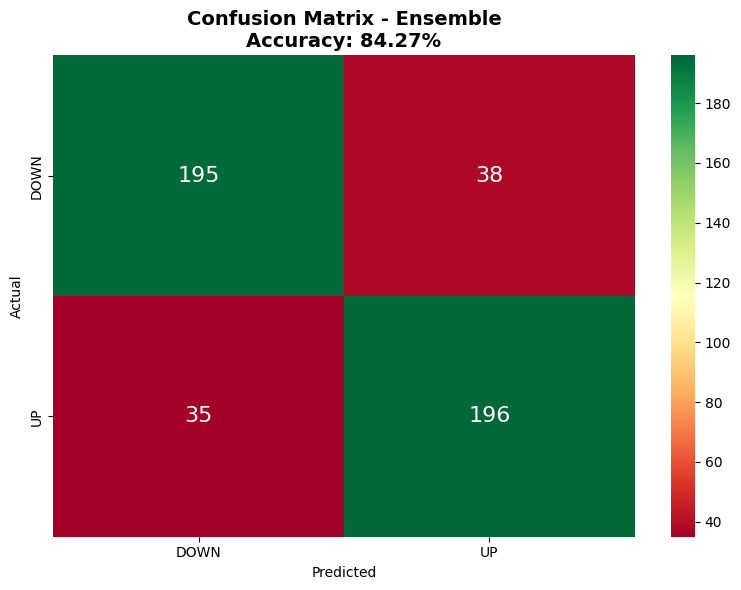

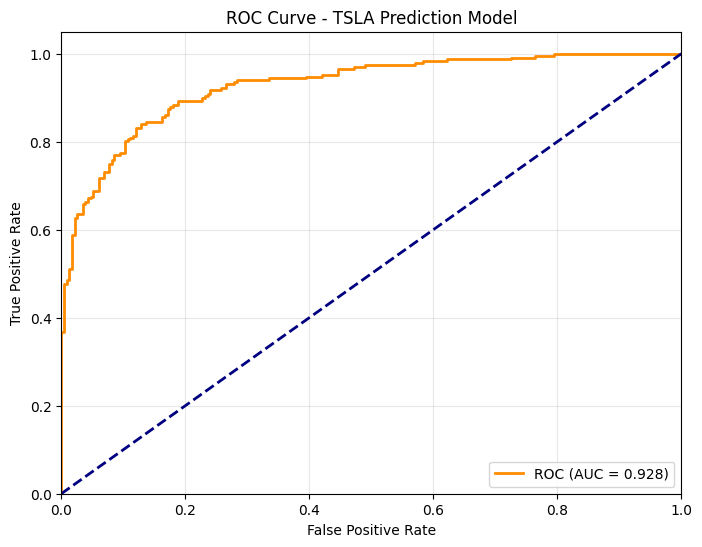

In [17]:

# CLASSIFICATION REPORT

print("CLASSIFICATION REPORT")

print(classification_report(y_test, ensemble_final,
                           target_names=['DOWN (0)', 'UP (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, ensemble_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['DOWN', 'UP'], yticklabels=['DOWN', 'UP'],
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - Ensemble\nAccuracy: {ensemble_acc*100:.2f}%',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, ensemble_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {ensemble_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TSLA Prediction Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# **STEP 10: BACKTEST WITH REALISTIC COSTS**

In [19]:

# BACKTEST WITH REALISTIC COSTS

print("BACKTESTING")

def backtest(predictions, prices, dates, initial_capital=100000, bet_size=0.2, cost_bps=10):
    capital = initial_capital
    position = 0
    trades = []
    equity = [initial_capital]
    cost = cost_bps / 10000

    for i in range(1, len(predictions)):
        price = prices.iloc[i]

        if predictions[i-1] == 1 and position == 0:
            shares = int(capital * bet_size / price)
            if shares > 0:
                capital -= shares * price * (1 + cost)
                position = shares
                trades.append({'date': dates.iloc[i], 'type': 'BUY', 'price': price})

        elif predictions[i-1] == 1 and predictions[i] == 0 and position > 0:
            capital += position * price * (1 - cost)
            position = 0
            trades.append({'date': dates.iloc[i], 'type': 'SELL', 'price': price})

        equity.append(capital + (position * price if position > 0 else 0))

    if position > 0:
        capital += position * prices.iloc[-1] * (1 - cost)
        equity[-1] = capital

    equity_series = pd.Series(equity, index=prices.index)
    returns = equity_series.pct_change().dropna()

    # Calculate win rate
    buys = [t for t in trades if t['type'] == 'BUY']
    sells = [t for t in trades if t['type'] == 'SELL']
    wins = sum(1 for i in range(min(len(buys), len(sells))) if sells[i]['price'] > buys[i]['price'])
    win_rate = (wins / len(sells) * 100) if sells else 0

    return {
        'return': (capital - initial_capital) / initial_capital * 100,
        'sharpe': np.sqrt(252) * returns.mean() / returns.std() if returns.std() > 0 else 0,
        'win_rate': win_rate,
        'trades': len(sells),
        'equity': equity_series,
        'final_capital': capital
    }

test_prices = df_feat['Close'].iloc[split_idx:].reset_index(drop=True)
test_dates = df_feat['Date'].iloc[split_idx:].reset_index(drop=True)

bk = backtest(ensemble_final, test_prices, test_dates)

print(f"💰 BACKTEST RESULTS")
print("-"*50)
print(f"Initial Capital:    ${100000:,.2f}")
print(f"Final Capital:      ${bk['final_capital']:,.2f}")
print(f"Total Return:       {bk['return']:.2f}%")
print(f"Sharpe Ratio:       {bk['sharpe']:.2f}")
print(f"Win Rate:           {bk['win_rate']:.1f}%")
print(f"Total Trades:       {bk['trades']}")

# Buy & Hold comparison
bh_return = (test_prices.iloc[-1] / test_prices.iloc[0] - 1) * 100
print(f"\n📊 VS BUY & HOLD:")
print(f"Strategy Return:    {bk['return']:.2f}%")
print(f"Buy & Hold Return:  {bh_return:.2f}%")
print(f"Excess Return:      {bk['return'] - bh_return:.2f}%")

BACKTESTING
💰 BACKTEST RESULTS
--------------------------------------------------
Initial Capital:    $100,000.00
Final Capital:      $138,487.55
Total Return:       38.49%
Sharpe Ratio:       2.17
Win Rate:           69.9%
Total Trades:       83

📊 VS BUY & HOLD:
Strategy Return:    38.49%
Buy & Hold Return:  107.59%
Excess Return:      -69.11%


# **STEP 11: INTERACTIVE DASHBOARD**

In [20]:

# INTERACTIVE DASHBOARD

print("GENERATING DASHBOARD")

# Prepare data
equity_curve = bk['equity']
bh_equity = 100000 * (test_prices / test_prices.iloc[0])
returns = equity_curve.pct_change().dropna() * 100
drawdown = (equity_curve / equity_curve.cummax() - 1) * 100

# Create dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '<b>📈 Equity Curve</b>',
        '<b>📊 Return Distribution</b>',
        '<b>📉 Drawdown Analysis</b>',
        '<b>🏆 Model Performance</b>'
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.12
)

# Equity Curve
fig.add_trace(
    go.Scatter(x=test_dates, y=equity_curve, name='Strategy',
               line=dict(color='#2E86AB', width=2.5), fill='tozeroy'),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=test_dates, y=bh_equity, name='Buy & Hold',
               line=dict(color='#E74C3C', width=2, dash='dash')),
    row=1, col=1
)

# Return Distribution
fig.add_trace(
    go.Histogram(x=returns, nbinsx=40, name='Returns',
                 marker_color='#A23B72', opacity=0.7),
    row=1, col=2
)
fig.add_vline(x=0, line_dash="dash", line_color="red", row=1, col=2)

# Drawdown
fig.add_trace(
    go.Scatter(x=test_dates, y=drawdown, name='Drawdown',
               line=dict(color='#E74C3C', width=2), fill='tozeroy'),
    row=2, col=1
)

# Model Performance
model_names = list(results.keys())
model_scores = [results[m]['accuracy'] * 100 for m in model_names]
colors = ['#2ECC71' if s >= 80 else '#F39C12' if s >= 70 else '#E74C3C' for s in model_scores]
fig.add_trace(
    go.Bar(x=model_names, y=model_scores, name='Accuracy',
           marker_color=colors,
           text=[f'{s:.1f}%' for s in model_scores], textposition='outside'),
    row=2, col=2
)
fig.add_hline(y=ensemble_acc*100, line_dash="dash", line_color="#27AE60",
              annotation_text=f"Ensemble: {ensemble_acc*100:.1f}%", row=2, col=2)

# Layout
fig.update_layout(
    height=700,
    showlegend=True,
    title_text=f"<b>🚀 TSLA TRADING SYSTEM - {ensemble_acc*100:.1f}% ACCURACY</b>",
    template='plotly_white'
)

fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_yaxes(title_text="Portfolio Value ($)", row=1, col=1)
fig.update_xaxes(title_text="Return (%)", row=1, col=2)
fig.update_yaxes(title_text="Frequency", row=1, col=2)
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Drawdown (%)", row=2, col=1)
fig.update_xaxes(title_text="Model", row=2, col=2)
fig.update_yaxes(title_text="Accuracy (%)", row=2, col=2, range=[0, 100])

fig.show()

print("\n✅ Dashboard Generated!")

GENERATING DASHBOARD



✅ Dashboard Generated!


# **STEP 12: SAVE MODEL**

In [21]:

# SAVE MODEL

import joblib
from datetime import datetime

print("SAVING MODEL")

# Find best model
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_name]['model']

# Create model package
model_package = {
    'model': best_model,
    'scaler': scaler,
    'features': selected_features,
    'accuracy': results[best_name]['accuracy'],
    'ensemble_accuracy': ensemble_acc,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

joblib.dump(model_package, 'tsla_model.pkl')
print(f"✅ Best Model: {best_name}")
print(f"✅ Accuracy: {results[best_name]['accuracy']*100:.2f}%")
print(f"✅ Ensemble Accuracy: {ensemble_acc*100:.2f}%")
print(f"✅ Saved to: tsla_model.pkl")

SAVING MODEL
✅ Best Model: GradientBoosting
✅ Accuracy: 85.13%
✅ Ensemble Accuracy: 84.27%
✅ Saved to: tsla_model.pkl


# **STEP 13: PREDICT TOMORROW**

In [22]:

# PREDICT TOMORROW

print("TOMORROW'S PREDICTION")

def predict_tomorrow(model_pkg, latest_df):
    feat_df = create_features(latest_df)
    latest = feat_df[model_pkg['features']].iloc[-1:].fillna(0)
    scaled = model_pkg['scaler'].transform(latest)
    pred = model_pkg['model'].predict(scaled)[0]
    proba = model_pkg['model'].predict_proba(scaled)[0]

    return {
        'direction': 'UP 📈' if pred == 1 else 'DOWN 📉',
        'confidence': proba[pred] * 100
    }

# Load and predict
loaded_model = joblib.load('tsla_model.pkl')
prediction = predict_tomorrow(loaded_model, df.tail(100))

print(f"📅 Today: {df['Date'].iloc[-1].date()}")
print(f"💰 Price: ${df['Close'].iloc[-1]:.2f}")
print(f"\n🔮 TOMORROW:")
print(f"   Direction: {prediction['direction']}")
print(f"   Confidence: {prediction['confidence']:.2f}%")

TOMORROW'S PREDICTION
📅 Today: 2024-12-30
💰 Price: $419.40

🔮 TOMORROW:
   Direction: DOWN 📉
   Confidence: 90.13%
